In [ ]:
%load_ext autoreload
%autoreload 2

# 01 — ProteinGym Pilot Exploration

Quick summary stats on the downloaded ProteinGym DMS substitution zero-shot scores.

**Run `python download_data.py` first** to populate `data/raw/`.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.data.proteingym_loader import load_dms_scores

Matplotlib is building the font cache; this may take a moment.


## Load data

We load the first 20 assays to keep memory manageable during exploration.
Remove `n_proteins=20` to load the full dataset (~4.4 GB).

In [2]:
df = load_dms_scores(data_dir="../data/raw", n_proteins=20)

Loading assays: 100%|██████████| 20/20 [00:02<00:00,  8.66assay/s]



Proteins (UniProt IDs) : 19
DMS assays             : 20
Zero-shot models       : 96
Total variant rows     : 103,029
Models found           : ['Site_Independent', 'EVmutation', 'DeepSequence_single', 'DeepSequence_ensemble', 'EVE_single', 'EVE_ensemble']...



In [3]:
df.head(3)

,protein_id,dms_id,mutant,position,wt_aa,mut_aa,experimental_fitness,Site_Independent,EVmutation,DeepSequence_single,...,xTrimoPGLM-3B-CLM,xTrimoPGLM-7B-CLM,xTrimoPGLM-100B-int4,Progen3_112m,Progen3_219m,Progen3_339m,Progen3_762m,Progen3_1b,Progen3_3b,DMS_bin_score
0,A0A140D2T1_ZIKV,A0A140D2T1_ZIKV_Sourisseau_2019,I291A,291,I,A,0.030269,-0.631373,-5.749302,-11.926361,...,-0.008161,0.001220,-11.065815,-2.599363,-2.202649,-1.831901,-1.391730,-0.747516,-0.362634,NaN
1,A0A140D2T1_ZIKV,A0A140D2T1_ZIKV_Sourisseau_2019,I291Y,291,I,Y,0.048604,-6.080533,-8.234701,-12.369904,...,-0.008148,0.000104,-13.393940,-2.598852,-2.203526,-1.833393,-1.394300,-0.749745,-0.365659,NaN
2,A0A140D2T1_ZIKV,A0A140D2T1_ZIKV_Sourisseau_2019,I291W,291,I,W,0.093642,-6.436738,-8.296883,-12.609741,...,-0.015063,-0.000582,-14.956440,-2.599863,-2.205054,-1.836223,-1.397921,-0.750662,-0.364957,NaN


## Summary statistics

In [4]:
fixed_cols = ["protein_id", "dms_id", "mutant", "position", "wt_aa", "mut_aa", "experimental_fitness"]
model_cols = [c for c in df.columns if c not in fixed_cols]

print(f"Proteins (UniProt):      {df['protein_id'].nunique()}")
print(f"DMS assays:              {df['dms_id'].nunique()}")
print(f"Zero-shot models:        {len(model_cols)}")
print(f"Total variants:          {len(df):,}")
print(f"Single mutants:          {df['position'].notna().sum():,}")
print(f"Multi-mutants:           {df['position'].isna().sum():,}")
print(f"Has experimental score:  {df['experimental_fitness'].notna().sum():,}")
print()
print("Models:")
for m in model_cols:
    print(f"  {m}")

Proteins (UniProt):      19
DMS assays:              20
Zero-shot models:        96
Total variants:          103,029
Single mutants:          85,195
Multi-mutants:           17,834
Has experimental score:  103,029

Models:
  Site_Independent
  EVmutation
  DeepSequence_single
  DeepSequence_ensemble
  EVE_single
  EVE_ensemble
  Unirep
  Unirep_evotune
  MSA_Transformer_single
  MSA_Transformer_ensemble
  ESM1b
  ESM1v_single
  ESM1v_ensemble
  ESM2_8M
  ESM2_35M
  ESM2_150M
  ESM2_650M
  ESM2_3B
  ESM2_15B
  Wavenet
  RITA_s
  RITA_m
  RITA_l
  RITA_xl
  Progen2_small
  Progen2_medium
  Progen2_base
  Progen2_large
  Progen2_xlarge
  GEMME
  VESPA
  VESPAl
  VespaG
  ProtGPT2
  Tranception_S_no_retrieval
  Tranception_M_no_retrieval
  Tranception_L_no_retrieval
  Tranception_S
  Tranception_M
  Tranception_L
  TranceptEVE_S
  TranceptEVE_M
  TranceptEVE_L
  CARP_38M
  CARP_600K
  CARP_640M
  CARP_76M
  MIF
  MIFST
  ESM-IF1
  ProteinMPNN
  ProtSSN_k10_h512
  ProtSSN_k10_h768
  ProtSSN

## Variants per assay

In [5]:
variants_per_assay = df.groupby("dms_id").size().sort_values(ascending=False)
print(variants_per_assay.describe().to_string())
print()
print(variants_per_assay.to_string())

count       20.000000
mean      5151.450000
std       4825.058478
min        170.000000
25%       1632.750000
50%       2661.000000
75%       8244.000000
max      14811.000000

dms_id
A4_HUMAN_Seuma_2022                     14811
A4D664_9INFA_Soh_2019                   14421
A0A192B1T2_9HIV1_Haddox_2018            12577
A0A2Z5U3Z0_9INFA_Doud_2016              10715
A0A140D2T1_ZIKV_Sourisseau_2019          9576
ADRB2_HUMAN_Jones_2020                   7800
AMIE_PSEAE_Wrenbeck_2017                 6227
A4GRB6_PSEAI_Chen_2020                   5004
ANCSZ_Hobbs_2022                         4670
AMFR_HUMAN_Tsuboyama_2023_4G3O           2972
A0A2Z5U3Z0_9INFA_Wu_2014                 2350
ACE2_HUMAN_Chan_2020                     2223
BBC1_YEAST_Tsuboyama_2023_1TG0           2069
AACC1_PSEAI_Dandage_2018                 1801
A0A247D711_LISMN_Stadelmann_2021         1653
BCHB_CHLTE_Tsuboyama_2023_2KRU           1572
ARGR_ECOLI_Tsuboyama_2023_1AOY           1287
A0A1I9GEU1_NEIME_Kennouche_2019   

## Distribution of variant counts across assays

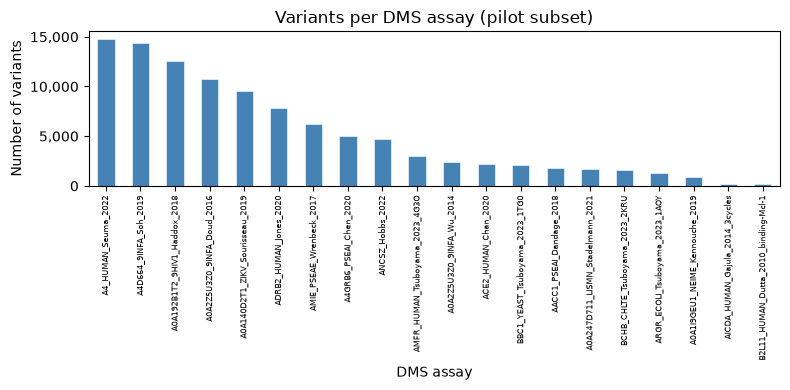

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
variants_per_assay.plot.bar(ax=ax, color="steelblue", edgecolor="white", linewidth=0.4)
ax.set_xlabel("DMS assay")
ax.set_ylabel("Number of variants")
ax.set_title("Variants per DMS assay (pilot subset)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis="x", labelsize=6, rotation=90)
plt.tight_layout()
plt.show()

## Missing model scores per assay

In [7]:
missing = df.groupby("dms_id")[model_cols].apply(lambda g: g.isna().mean().mean())
missing = missing.sort_values(ascending=False)
print("Mean fraction of missing model scores per assay:")
print(missing.to_string())

Mean fraction of missing model scores per assay:
dms_id
A0A140D2T1_ZIKV_Sourisseau_2019         0.010417
A0A192B1T2_9HIV1_Haddox_2018            0.010417
BBC1_YEAST_Tsuboyama_2023_1TG0          0.010417
B2L11_HUMAN_Dutta_2010_binding-Mcl-1    0.010417
ARGR_ECOLI_Tsuboyama_2023_1AOY          0.010417
AMIE_PSEAE_Wrenbeck_2017                0.010417
AMFR_HUMAN_Tsuboyama_2023_4G3O          0.010417
AICDA_HUMAN_Gajula_2014_3cycles         0.010417
ADRB2_HUMAN_Jones_2020                  0.010417
ACE2_HUMAN_Chan_2020                    0.010417
AACC1_PSEAI_Dandage_2018                0.010417
A4_HUMAN_Seuma_2022                     0.010417
A4GRB6_PSEAI_Chen_2020                  0.010417
A4D664_9INFA_Soh_2019                   0.010417
A0A2Z5U3Z0_9INFA_Wu_2014                0.010417
A0A2Z5U3Z0_9INFA_Doud_2016              0.010417
A0A247D711_LISMN_Stadelmann_2021        0.010417
A0A1I9GEU1_NEIME_Kennouche_2019         0.010417
BCHB_CHLTE_Tsuboyama_2023_2KRU          0.010417
ANCSZ_Hobbs_2

## Experimental fitness distribution (where available)

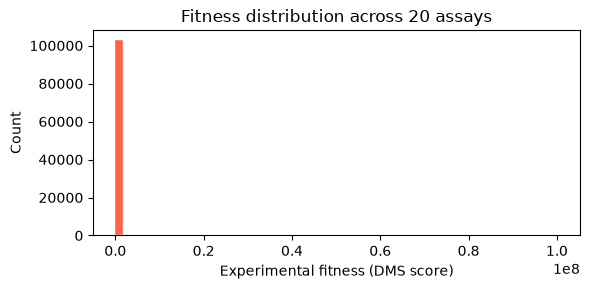

In [8]:
fit = df["experimental_fitness"].dropna()
if len(fit):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(fit, bins=60, color="tomato", edgecolor="white", linewidth=0.3)
    ax.set_xlabel("Experimental fitness (DMS score)")
    ax.set_ylabel("Count")
    ax.set_title(f"Fitness distribution across {df['dms_id'].nunique()} assays")
    plt.tight_layout()
    plt.show()
else:
    print("No experimental fitness values found in this subset.")
    print("They may live in the DMS assay files rather than the zero-shot score files.")

In [9]:
pilot_targets = ["P04637", "P38398", "P62593", "P60484", "P42212"]  
# TP53, BRCA1, TEM-1 beta-lactamase, PTEN, GFP

df_meta = pd.read_csv("data/raw/DMS_substitutions.csv")  # or wherever metadata lives
df_meta[df_meta["UniProt_ID"].isin(pilot_targets)][["DMS_id", "UniProt_ID", "target_seq"]]

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/DMS_substitutions.csv'

In [10]:
df[["experimental_fitness", "DMS_bin_score"]].corr()


,experimental_fitness,DMS_bin_score
experimental_fitness,1.000000,0.682493
DMS_bin_score,0.682493,1.000000


In [11]:
pilots = [
    "A4_HUMAN_Seuma_2022",
    "ADRB2_HUMAN_Jones_2020",
    "ACE2_HUMAN_Chan_2020",
    "AMIE_PSEAE_Wrenbeck_2017",
    "A0A192B1T2_9HIV1_Haddox_2018",
]

found = df[df["dms_id"].isin(pilots)]
print(f"Found {found['dms_id'].nunique()} of {len(pilots)} pilot assays")
print(found.groupby("dms_id").size())

Found 5 of 5 pilot assays
dms_id
A0A192B1T2_9HIV1_Haddox_2018    12577
A4_HUMAN_Seuma_2022             14811
ACE2_HUMAN_Chan_2020             2223
ADRB2_HUMAN_Jones_2020           7800
AMIE_PSEAE_Wrenbeck_2017         6227
dtype: int64
